In [5]:
import jax.numpy as jnp
from matplotlib import pyplot as plt 

In [25]:
dataset = []
with open('./datasets/optical+recognition+of+handwritten+digits/optdigits.tes', "r") as f:
    for i, line in enumerate(f):
        dataset.append([int(y) for y in line.split(',')])
dataset = jnp.array(dataset)


In [26]:
images = []
labels = []
for case in dataset:
    image = case[:64].reshape(8,8)
    label = case[-1] 
    label_one_hot = [0]*10
    label_one_hot[label] = 1
    images.append(image)
    labels.append(label_one_hot)
images = jnp.array(images)
labels = jnp.array(labels)

Text(0.5, 1.0, '[1 0 0 0 0 0 0 0 0 0]')

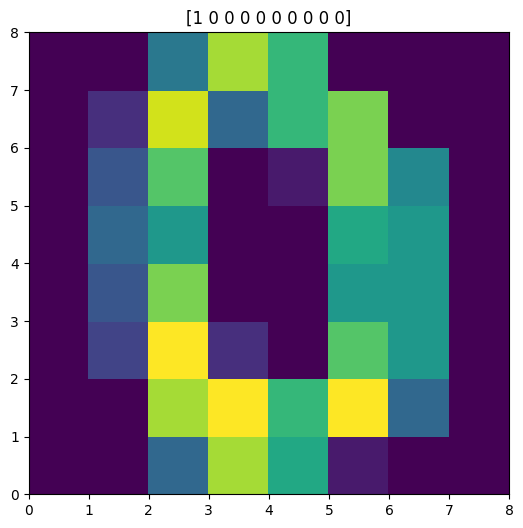

In [ ]:
plt.figure(figsize=(6.2,6))
index = 0
plt.pcolor(images[index])
plt.title(labels[index])

In [39]:
highest_val = 0
for case in dataset:
    for num in case:
        if num > highest_val:
            highest_val = num
        else:
            continue
print(highest_val)

16


In [24]:

def OptDigits_extract_and_convert(filename):
    dataset = []
    with open(filename, "r") as f:
        for i, line in enumerate(f):
            dataset.append([int(y) for y in line.split(',')])
    dataset = jnp.array(dataset)
    images = []
    labels = []
    for case in dataset:
        image = case[:64].reshape(8,8)
        label = case[-1] 
        label_one_hot = [0]*10
        label_one_hot[label] = 1
        images.append(image)
        labels.append(label_one_hot)
    images = jnp.array(images)
    labels = jnp.array(labels)
    return images, labels
# converting to amplitudes:
def OptDigits_SL_map_features_and_labels(feature_multiplier, feature_constant, label_multiplier, amplitudes, outputn):
    
    amplitude_relative = jnp.mean(amplitudes[jnp.array(outputn)])
    
    images, labels = OptDigits_extract_and_convert('./datasets/optical+recognition+of+handwritten+digits/optdigits.tes')
    # first divided by 16 to sort of normalize
    features_converted = images * 0.0625 * feature_multiplier + feature_constant
    # shifted to match XOR definition
    labels_converted = (labels - 0.5) * 2  * label_multiplier + amplitude_relative

    return amplitude_relative, features_converted, labels_converted

In [9]:
a, f, l = OptDigits_SL_map_features_and_labels(1,1,1,jnp.array([1,1,1]),[1])

In [22]:
jnp.arange(64,74,1)

Array([64, 65, 66, 67, 68, 69, 70, 71, 72, 73], dtype=int32)

In [3]:
import numpy as np
import math

array([[0., 1., 0., ..., 0., 0., 0.],
       [1., 0., 1., ..., 0., 0., 0.],
       [0., 1., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 1., 0.],
       [0., 0., 0., ..., 1., 0., 1.],
       [0., 0., 0., ..., 0., 1., 0.]])

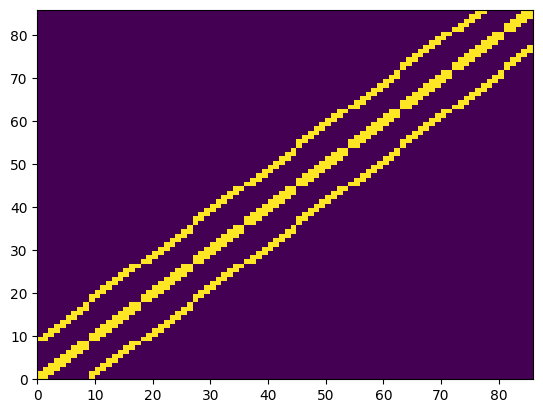

In [26]:
def generate_triangular_lattice_weights(n_points, visualize=False):
    """
    Generate a weight matrix for a triangular lattice with nearest neighbor connections.
    
    Parameters:
    n_points (int): Number of points in the lattice
    
    Returns:
    tuple: (points, weight_matrix) where:
        - points: 2D coordinates of points in the lattice
        - weight_matrix: Adjacency matrix with weights (1 for connected, 0 otherwise)
    """
    height = round(math.sqrt(n_points * 2 / math.sqrt(3)))
    if height < 1:
        height = 1
    
    # Generate coordinates for triangular lattice
    points = []
    for i in range(height):
        x_offset = 0.5 if i % 2 else 0
        row_width = round(n_points / height)
        for j in range(row_width):
            x = j + x_offset
            y = i * math.sqrt(3)/2
            points.append([x, y])
    
    # If we generated too many points, trim the list
    points = np.array(points[:n_points])

    connections_neuronwise = np.zeros((n_points, n_points))
    dist_matrix = np.zeros((n_points, n_points))
    for i in range(n_points):
        for j in range(n_points):
            dist_matrix[i,j] = np.linalg.norm(points[i] - points[j])
    
    # Find the smallest non-zero distance to determine connection threshold (nearest-neighbor)
    min_dist = np.min(dist_matrix[dist_matrix > 0])
    connection_threshold = min_dist * 1.1
    for i in range(n_points):
        for j in range(i+1, n_points):
            if dist_matrix[i,j] < connection_threshold:
                connections_neuronwise[i,j] = 1
                connections_neuronwise[j,i] = 1
    
    if visualize:
        import matplotlib.pyplot as plt
        plt.figure(figsize=(8, 8))
        plt.scatter(points[:, 0], points[:, 1])
        plt.figure(figsize=(8, 8))
        plt.scatter(points[:, 0], points[:, 1])
        for i in range(n):
            for j in range(i+1, n):
                if weights[i,j] > 0:
                    plt.plot([points[i,0], points[j,0]], [points[i,1], points[j,1]], 'b-', alpha=0.3)
        plt.title('Triangular Lattice with Nearest Neighbor Connections')
        plt.show()

    return jnp.array(connections_neuronwise) + jnp.eye(n_points)

# Example usage:
n = 86  # Number of points
connections_neuronwise = generate_triangular_lattice_weights(n)

# To visualize the lattice and connections:


plt.pcolor(connections_neuronwise)
points

In [29]:
jnp.arange(0,9,1)

Array([0, 1, 2, 3, 4, 5, 6, 7, 8], dtype=int32)

In [46]:
def OptDigits_separate_training_and_test(features, labels):
    check = jnp.zeros(10)
    training_features = []
    training_labels = []
    test_features = []
    test_labels = []
    for f, l in zip(features,labels):
        check += l
        label = jnp.argmax(l)
        if check[label] < 121:
            training_features.append(f)
            training_labels.append(l)
        else:
            test_features.append(f)
            test_labels.append(l)
    print(check)
    return jnp.array(training_features), jnp.array(training_labels), jnp.array(test_features), jnp.array(test_labels)

trf, trl, tef, tel = OptDigits_separate_training_and_test(images, labels)

[178. 182. 177. 183. 181. 182. 181. 179. 174. 180.]


In [50]:
jnp.sum(jnp.sum(trl,axis=0))

Array(1200, dtype=int32)

In [33]:
trl[0]

Array([1, 0, 0, 0, 0, 0, 0, 0, 0, 0], dtype=int32)

In [25]:
jnp.array([178., 182., 177., 183., 181., 182., 181., 179., 174., 180.])-121

Array([57., 61., 56., 62., 60., 61., 60., 58., 53., 59.], dtype=float32)

In [52]:
int(jnp.argmax(jnp.array([1,2,3,7,2,5])))

3

In [ ]:
jnp.zeros()